In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree

import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
from google.colab import files

uploaded = files.upload()

Saving Raisin_Dataset.xlsx to Raisin_Dataset (2).xlsx


In [24]:
file_name = 'Raisin_Dataset.xlsx'

_df = pd.read_excel(file_name)

_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [25]:
_df.info()

_df.shape

_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [26]:
_df.isnull().sum()

,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
Extent,0
Perimeter,0
Class,0


In [27]:
X = _df.drop('Class', axis=1)

y = _df['Class']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Jumlah data training :', X_train.shape)
print('Jumlah data testing  :', X_test.shape)

Jumlah data training : (720, 7)
Jumlah data testing  : (180, 7)


In [29]:
model1 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    max_depth=5
)

model1.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [30]:
y_pred1 = model1.predict(X_test)

Akurasi Model Percobaan 1 : 0.85
              precision    recall  f1-score   support

       Besni       0.91      0.78      0.84        90
     Kecimen       0.81      0.92      0.86        90

    accuracy                           0.85       180
   macro avg       0.86      0.85      0.85       180
weighted avg       0.86      0.85      0.85       180



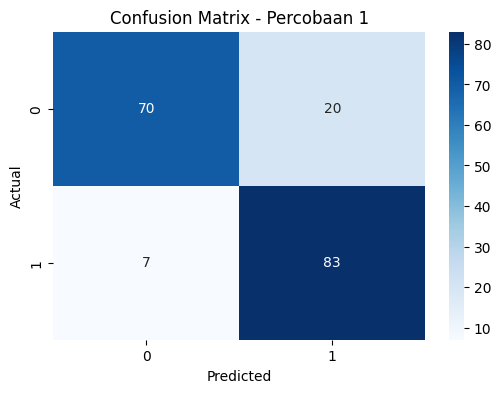

In [31]:
acc1 = accuracy_score(y_test, y_pred1)
print('Akurasi Model Percobaan 1 :', acc1)

print(classification_report(y_test, y_pred1))

cm1 = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(6,4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Percobaan 1')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

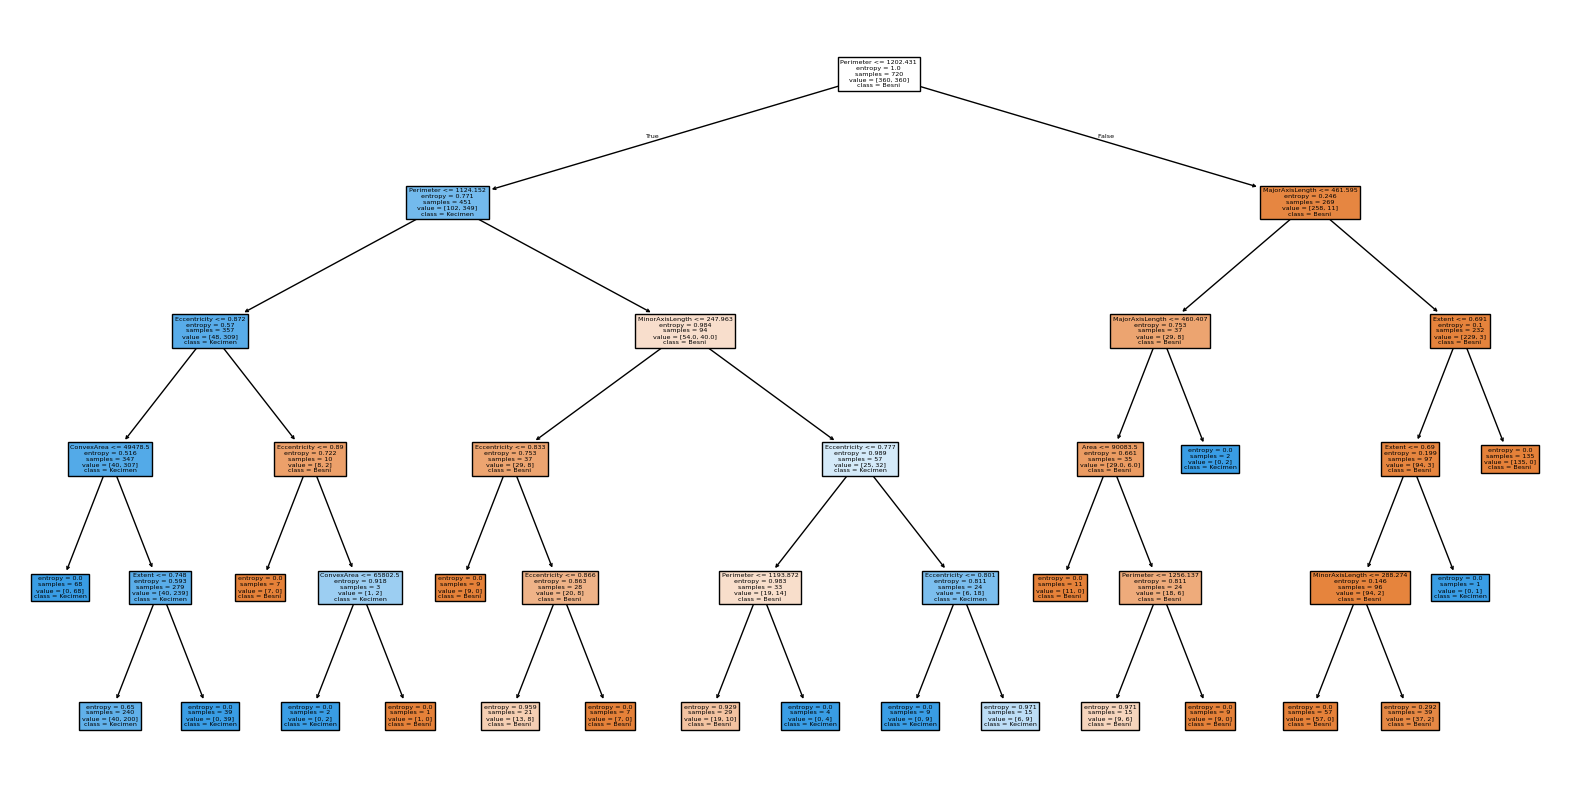

In [32]:
plt.figure(figsize=(20,10))

tree.plot_tree(
    model1,
    feature_names=X.columns,
    class_names=model1.classes_,
    filled=True
)

plt.show()

In [33]:
model2 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    max_depth=3
)

model2.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [34]:
y_pred2 = model2.predict(X_test)

Akurasi Model Percobaan 2 : 0.8611111111111112
              precision    recall  f1-score   support

       Besni       0.95      0.77      0.85        90
     Kecimen       0.80      0.96      0.87        90

    accuracy                           0.86       180
   macro avg       0.87      0.86      0.86       180
weighted avg       0.87      0.86      0.86       180



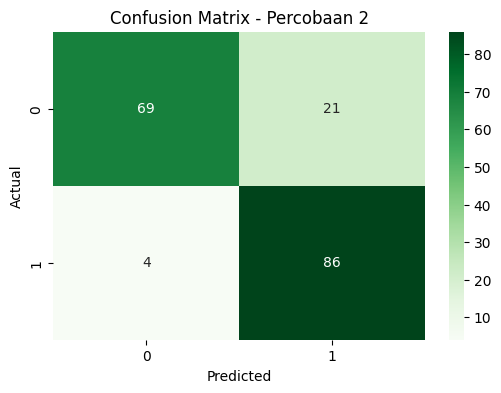

In [35]:
acc2 = accuracy_score(y_test, y_pred2)
print('Akurasi Model Percobaan 2 :', acc2)

print(classification_report(y_test, y_pred2))

cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Percobaan 2')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

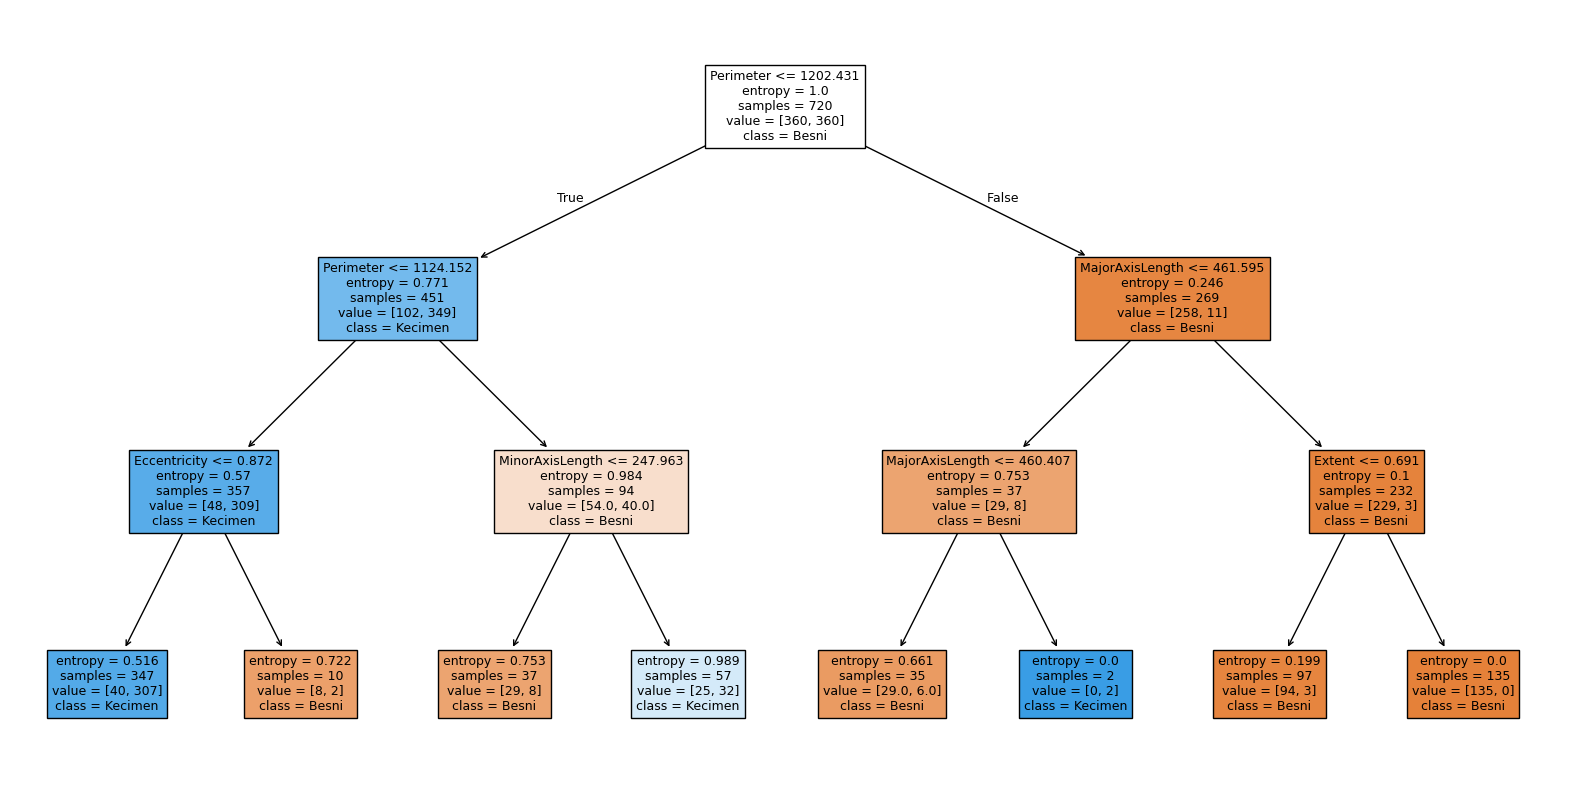

In [36]:
plt.figure(figsize=(20,10))

tree.plot_tree(
    model2,
    feature_names=X.columns,
    class_names=model2.classes_,
    filled=True
)

plt.show()

In [37]:
print('===== HASIL PERBANDINGAN =====')
print(f'Akurasi Percobaan 1 : {acc1}')
print(f'Akurasi Percobaan 2 : {acc2}')

===== HASIL PERBANDINGAN =====
Akurasi Percobaan 1 : 0.85
Akurasi Percobaan 2 : 0.8611111111111112


In [38]:
hasil = pd.DataFrame({
    'Actual': y_test,
    'Prediksi_Percobaan1': y_pred1,
    'Prediksi_Percobaan2': y_pred2
})

# Simpan ke CSV
file_output = 'hasil_prediksi_decision_tree.csv'
hasil.to_csv(file_output, index=False)

print('File berhasil disimpan:', file_output)

from google.colab import files

files.download(file_output)

File berhasil disimpan: hasil_prediksi_decision_tree.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>